In [1]:
!pip install timm mamba-ssm torchmetrics einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 30.6 MB/s eta 0:00:00
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
  Created wheel for mamba-ssm: filename=mamba_ssm-2.2.5-cp312-cp312-linux_x86_64.whl size=532566033 sha256=c8b65fcabfb49a94456c9971619007218e4073f19a84fb6b3894f33d43bee4a1
  Stored in directory: /root/.cache/pip/wheels/21/55/c4/85b634055d6a9b599d27f5cbeacf353c6c532d8e2d8769960b
Successfully built mamba-ssm


In [2]:
import os, random, time, math, pathlib, numpy as np, torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
set_seed(42)

Torch: 2.8.0+cu126 | CUDA: True


In [3]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

# CIFAR‑10 class names for pretty logs
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

NUM_CLASSES = 10
IMG_SIZE = 224
TRAIN_PER_CLASS = 100   # small & fast: 1000 train images total
VAL_PER_CLASS   = 20    # 200 val images
BATCH_SIZE = 32
EPOCHS = 8

# ImageNet mean/std (also present in the HF config for MambaVision-T-1K)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

root = "./data"
train_full = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=train_tfms)
val_full   = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=val_tfms)

def stratified_indices(targets, per_class):
    idxs = []
    targets = np.array(targets)
    for c in range(NUM_CLASSES):
        idxs.extend(np.where(targets == c)[0][:per_class].tolist())
    random.shuffle(idxs); return idxs

train_targets = torchvision.datasets.CIFAR10(root=root, train=True, download=False).targets
val_targets   = torchvision.datasets.CIFAR10(root=root, train=False, download=False).targets

train_idx = stratified_indices(train_targets, TRAIN_PER_CLASS)
val_idx   = stratified_indices(val_targets, VAL_PER_CLASS)

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(val_full, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds)


100%|██████████| 170M/170M [00:05<00:00, 31.9MB/s]


(1000, 200)

In [8]:
import torch.nn as nn
from transformers import AutoModelForImageClassification

HF_ID = "nvidia/MambaVision-T-1K"  # official tiny ImageNet-1K checkpoint

model = AutoModelForImageClassification.from_pretrained(
    HF_ID, trust_remote_code=True
)

# Replace classification head to 10 classes (important: do this BEFORE .to(device))
# MambaVision's HF wrapper uses `model.head(...)` for classification.
in_features = model.model.head.in_features
model.model.head = nn.Linear(in_features, 10)


# Set label maps (nice-to-have; helps logs / saved config)
model.config.num_labels = NUM_CLASSES
model.config.id2label = {i: c for i, c in enumerate(CIFAR10_CLASSES)}
model.config.label2id = {c: i for i, c in enumerate(CIFAR10_CLASSES)}

# Move everything (including the new head) to GPU/CPU
model = model.to(device)

# Quick forward sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    out = model(dummy)
    print("Logits shape:", tuple(out["logits"].shape))


Logits shape: (2, 10)


In [9]:
from torch.cuda.amp import autocast, GradScaler

def accuracy_top1(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def cosine_lr(base_lr, step, total_steps, warmup_steps=0):
    if step < warmup_steps:
        return base_lr * float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

def train_one_epoch(model, loader, optimizer, scaler, criterion, epoch, total_epochs):
    model.train()
    total_loss = total_acc = n = 0
    for i, (images, targets) in enumerate(loader):
        images, targets = images.to(device, non_blocking=True), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=torch.cuda.is_available()):
            out = model(images)
            logits = out["logits"] if isinstance(out, dict) else out
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_top1(logits.detach(), targets) * bs
        n += bs
        if (i+1) % 100 == 0:
            print(f"Epoch {epoch+1:02d}/{total_epochs:02d} step {i+1:04d}/{len(loader):04d} "
                  f"loss={total_loss/n:.4f} acc={total_acc/n:.3f}")
    return total_loss/n, total_acc/n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_acc = n = 0
    for images, targets in loader:
        images, targets = images.to(device, non_blocking=True), targets.to(device)
        out = model(images)
        logits = out["logits"] if isinstance(out, dict) else out
        loss = criterion(logits, targets)
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_top1(logits, targets) * bs
        n += bs
    return total_loss/n, total_acc/n


In [10]:
@dataclass
class TrainCfg:
    epochs: int = EPOCHS
    lr: float = 5e-4
    weight_decay: float = 0.05
    warmup_epochs: int = 1

def run_experiment(model, name, cfg: TrainCfg):
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler = GradScaler(enabled=torch.cuda.is_available())

    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    steps_per_epoch = len(train_loader)
    gs = 0
    for ep in range(cfg.epochs):
        # cosine LR + short warmup
        for pg in optim.param_groups:
            pg["lr"] = cosine_lr(cfg.lr, gs, cfg.epochs*steps_per_epoch, warmup_steps=cfg.warmup_epochs*steps_per_epoch)
        lr_now = optim.param_groups[0]["lr"]

        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optim, scaler, criterion, ep, cfg.epochs)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        dt = time.time() - t0

        history["epoch"].append(ep+1)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(lr_now)

        print(f"[{name}] epoch {ep+1:02d}/{cfg.epochs:02d}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.3f}  lr={lr_now:.2e}  time={dt:.1f}s")
        gs += steps_per_epoch

    # Save metrics & weights
    outdir = pathlib.Path("runs")/name
    outdir.mkdir(parents=True, exist_ok=True)
    import pandas as pd, json
    torch.save(model.state_dict(), outdir/"final.pth")
    pd.DataFrame(history).to_csv(outdir/"metrics.csv", index=False)
    with open(outdir/"history.json", "w") as f: json.dump(history, f, indent=2)
    return history

cfg = TrainCfg(epochs=EPOCHS, lr=5e-4, weight_decay=0.05, warmup_epochs=1)
history = run_experiment(model, "mambavision_tiny_pretrained_cifar10", cfg)


/tmp/ipython-input-2007737807.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-2482681921.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


[mambavision_tiny_pretrained_cifar10] epoch 01/08  train_loss=2.3522  train_acc=0.051  val_loss=2.3207  val_acc=0.095  lr=0.00e+00  time=17.7s
[mambavision_tiny_pretrained_cifar10] epoch 02/08  train_loss=1.4724  train_acc=0.509  val_loss=1.9590  val_acc=0.390  lr=5.00e-04  time=6.1s
[mambavision_tiny_pretrained_cifar10] epoch 03/08  train_loss=0.8025  train_acc=0.719  val_loss=0.7287  val_acc=0.745  lr=4.75e-04  time=5.6s
[mambavision_tiny_pretrained_cifar10] epoch 04/08  train_loss=0.4910  train_acc=0.837  val_loss=0.9151  val_acc=0.715  lr=4.06e-04  time=5.3s
[mambavision_tiny_pretrained_cifar10] epoch 05/08  train_loss=0.3341  train_acc=0.887  val_loss=0.7019  val_acc=0.775  lr=3.06e-04  time=5.8s
[mambavision_tiny_pretrained_cifar10] epoch 06/08  train_loss=0.1878  train_acc=0.949  val_loss=0.5774  val_acc=0.830  lr=1.94e-04  time=5.3s
[mambavision_tiny_pretrained_cifar10] epoch 07/08  train_loss=0.1317  train_acc=0.961  val_loss=0.4687  val_acc=0.865  lr=9.41e-05  time=6.0s
[mamb

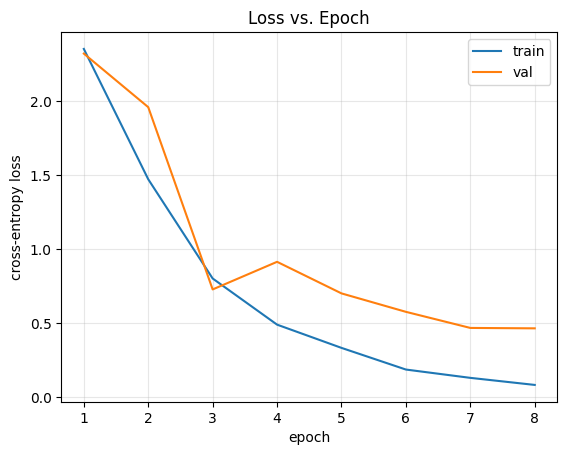

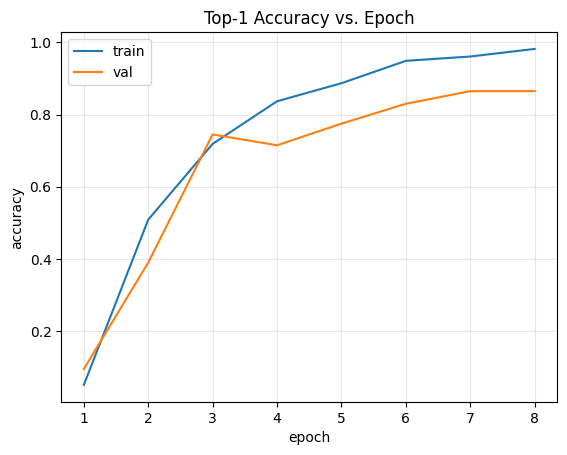


Final metrics → train_acc: 0.982 | val_acc: 0.865


In [11]:
from pathlib import Path

def plot_curves(hist, outdir="runs"):
    # Loss
    plt.figure()
    plt.title("Loss vs. Epoch")
    plt.plot(hist["epoch"], hist["train_loss"], label="train")
    plt.plot(hist["epoch"], hist["val_loss"],   label="val")
    plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.grid(True, alpha=0.3); plt.legend()
    Path(outdir).mkdir(parents=True, exist_ok=True)
    plt.savefig(f"{outdir}/loss_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

    # Accuracy
    plt.figure()
    plt.title("Top-1 Accuracy vs. Epoch")
    plt.plot(hist["epoch"], hist["train_acc"], label="train")
    plt.plot(hist["epoch"], hist["val_acc"],   label="val")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.grid(True, alpha=0.3); plt.legend()
    plt.savefig(f"{outdir}/accuracy_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

plot_curves(history, outdir="runs")
print("\nFinal metrics → train_acc: %.3f | val_acc: %.3f" % (history["train_acc"][-1], history["val_acc"][-1]))
